# ParkIntel — Notebook 1: Data Cleaning & Preprocessing
**Goal:** Raw CSV → `train.csv` + `test.csv` ready for model training.

### Pipeline overview
```
Raw CSV
  └─ 1. Load & inspect
  └─ 2. Parse timestamps
  └─ 3. Validate coordinates (Bangalore bounding box)
  └─ 4. Confidence-weight by validation_status
  └─ 5. Normalize text fields
  └─ 6. Parse & explode violation_type
  └─ 7. Normalize vehicle_type
  └─ 8. Create zone_id (lat/lon grid)
  └─ 9. Temporal feature extraction
  └─ 10. Hourly zone aggregations
  └─ 11. Rolling count features (1h / 3h / 24h / 7d)
  └─ 12. Violation-type & vehicle-severity breakdowns
  └─ 13. Repeat hotspot score
  └─ 14. Label creation (LOW / MEDIUM / HIGH)
  └─ 15. Time-based train/test split → save CSVs
```
> **Time-based split rule:** train on Jan–Apr, test on May.  
> This prevents any future-violation leakage in rolling features.

## 1. Imports & Config

In [1]:
import pandas as pd
import numpy as np
import json, ast, re, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.4f}".format)

# ── Paths ──────────────────────────────────────────────────────────────────
RAW_CSV    = Path("grid-r2-t1-dataset.csv")
TRAIN_OUT  = Path("train.csv")
TEST_OUT   = Path("test.csv")

# ── Bangalore bounding box ─────────────────────────────────────────────────
BLR_LAT_MIN, BLR_LAT_MAX = 12.70, 13.20
BLR_LON_MIN, BLR_LON_MAX = 77.30, 77.85

# ── Validation-status confidence weights ──────────────────────────────────
CONF_MAP = {
    "approved":    1.0,
    "created":     0.7,
    "processing":  0.6,
    "pending":     0.7,
    "rejected":    None,   # exclude
    "duplicate":   None,   # exclude
}

print("Config ready.")

Config ready.


## 2. Load Raw CSV & Initial Inspection

In [2]:
df = pd.read_csv(RAW_CSV, low_memory=False)
print(f"Shape: {df.shape}")
df.head(3)

Shape: (298450, 24)


,id,latitude,longitude,location,vehicle_number,vehicle_type,description,violation_type,offence_code,created_datetime,closed_datetime,modified_datetime,device_id,created_by_id,center_code,police_station,data_sent_to_scita,junction_name,action_taken_timestamp,data_sent_to_scita_timestamp,updated_vehicle_number,updated_vehicle_type,validation_status,validation_timestamp
0,FKID000000,12.9256,77.6187,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,CAR,NaN,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46+00,NaN,2023-11-28 04:48:04.582978+00,FKDEV00000,FKUSR00000,9.0000,Madiwala,True,No Junction,NaN,NaN,FKN00GL0000,MAXI-CAB,approved,2023-11-30 03:08:24.818+00
1,FKID000001,12.9055,77.7008,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,NaN,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00,NaN,2023-11-24 23:00:24.115257+00,FKDEV00001,FKUSR00001,82.0000,Bellandur,False,No Junction,NaN,NaN,NaN,NaN,NaN,NaN
2,FKID000002,12.9254,77.6185,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,CAR,NaN,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 00:27:46+00,NaN,2023-11-28 04:47:02.33776+00,FKDEV00000,FKUSR00000,9.0000,Madiwala,True,No Junction,NaN,NaN,FKN00GL0002,MAXI-CAB,approved,2023-11-30 03:08:56.998+00


In [3]:
# Column dtypes and null-counts
null_summary = pd.DataFrame({
    "dtype":    df.dtypes,
    "nulls":    df.isnull().sum(),
    "null_pct": (df.isnull().mean() * 100).round(2),
    "unique":   df.nunique(),
})
print(null_summary.to_string())

                                dtype   nulls  null_pct  unique
id                                str       0    0.0000  298450
latitude                      float64       0    0.0000  177982
longitude                     float64       0    0.0000  177378
location                          str    3041    1.0200   10942
vehicle_number                    str       0    0.0000  231890
vehicle_type                      str       0    0.0000      22
description                   float64  298450  100.0000       0
violation_type                    str       0    0.0000     991
offence_code                      str       0    0.0000     991
created_datetime                  str       0    0.0000   94417
closed_datetime               float64  298450  100.0000       0
modified_datetime                 str       0    0.0000  298450
device_id                         str       0    0.0000    3070
created_by_id                     str       5    0.0000    2666
center_code                   float64   

In [4]:
# Quick look at key categorical columns
for col in ["violation_type", "vehicle_type", "validation_status", "police_station"]:
    if col in df.columns:
        print(f"\n── {col} (top 10) ──")
        print(df[col].value_counts(dropna=False).head(10).to_string())


── violation_type (top 10) ──
violation_type
["WRONG PARKING"]                             138764
["NO PARKING"]                                119576
["PARKING IN A MAIN ROAD","WRONG PARKING"]      9472
["PARKING IN A MAIN ROAD","NO PARKING"]         4818
["WRONG PARKING","DEFECTIVE NUMBER PLATE"]      3317
["NO PARKING","PARKING IN A MAIN ROAD"]         2449
["NO PARKING","DEFECTIVE NUMBER PLATE"]         2380
["WRONG PARKING","PARKING IN A MAIN ROAD"]      1955
["PARKING ON FOOTPATH","WRONG PARKING"]         1190
["NO PARKING","WRONG PARKING"]                   891

── vehicle_type (top 10) ──
vehicle_type
SCOOTER           94856
CAR               88870
MOTOR CYCLE       40811
PASSENGER AUTO    37813
MAXI-CAB          11372
LGV                8255
GOODS AUTO         2934
MOPED              2199
PRIVATE BUS        1633
VAN                1466

── validation_status (top 10) ──
validation_status
NaN           125254
approved      115400
rejected       49754
created1        7044
proces

## 3. Parse Timestamps

In [5]:
df["created_datetime"] = pd.to_datetime(df["created_datetime"], utc=True, errors="coerce")

bad_dt = df["created_datetime"].isnull().sum()
print(f"Rows with unparseable datetime: {bad_dt} — dropping them.")
df = df.dropna(subset=["created_datetime"]).copy()

# Ensure the dataset covers Jan–May; trim anything outside
DATE_MIN = pd.Timestamp("2024-01-01", tz="UTC")
DATE_MAX = pd.Timestamp("2024-06-01", tz="UTC")
df = df[(df["created_datetime"] >= DATE_MIN) & (df["created_datetime"] < DATE_MAX)].copy()

print(f"Date range: {df['created_datetime'].min()} → {df['created_datetime'].max()}")
print(f"Shape after timestamp filter: {df.shape}")

Rows with unparseable datetime: 5 — dropping them.
Date range: 2024-01-01 00:00:46+00:00 → 2024-04-08 17:30:46+00:00
Shape after timestamp filter: (190774, 24)


## 4. Validate Coordinates (Bangalore Bounding Box)

In [6]:
df["latitude"]  = pd.to_numeric(df["latitude"],  errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

before = len(df)
df = df.dropna(subset=["latitude", "longitude"])
df = df[
    df["latitude"].between(BLR_LAT_MIN, BLR_LAT_MAX) &
    df["longitude"].between(BLR_LON_MIN, BLR_LON_MAX)
].copy()
after = len(df)

print(f"Dropped {before - after:,} rows with missing/out-of-bounds coordinates.")
print(f"Remaining: {after:,} rows")

Dropped 132 rows with missing/out-of-bounds coordinates.
Remaining: 190,642 rows


## 5. Handle Validation Status → Confidence Weight

In [7]:
df["validation_status"] = (
    df["validation_status"]
    .fillna("created")
    .str.lower()
    .str.strip()
)

# Map to confidence
df["record_confidence"] = df["validation_status"].map(CONF_MAP)

# Exclude rejected / duplicate
before = len(df)
df = df[df["record_confidence"].notnull()].copy()
df["record_confidence"] = df["record_confidence"].astype(float)

after = len(df)
print(f"Excluded {before - after:,} rejected/duplicate records.")
print(f"Confidence distribution:")
print(df["record_confidence"].value_counts().to_string())

Excluded 29,430 rejected/duplicate records.
Confidence distribution:
record_confidence
0.7000    114506
1.0000     46028
0.6000       678


## 6. Normalize Categorical Text Fields

In [8]:
def clean_str(s, fallback="UNKNOWN"):
    if pd.isna(s):
        return fallback
    return str(s).strip().upper()

NON_JUNCTION_VALUES = {
    "NO JUNCTION", "NO_JUNCTION", "NONE", "NA", "N/A",
    "NOT APPLICABLE", "NIL", "-", "", "NO JUNCTION NAME",
}

def normalize_junction(s):
    cleaned = clean_str(s, fallback="NO_JUNCTION")
    if cleaned in NON_JUNCTION_VALUES:
        return "NO_JUNCTION"
    return cleaned

df["police_station"] = df["police_station"].apply(lambda x: clean_str(x, "UNKNOWN_STATION"))
df["junction_name"]  = df["junction_name"].apply(normalize_junction)
df["location"]       = df["location"].apply(lambda x: clean_str(x, "UNKNOWN_LOCATION"))

if "description" in df.columns:
    df = df.drop(columns=["description"])
    print("Dropped 100%-null 'description' column.")

print("Sample police_station:", df["police_station"].value_counts().head(5).to_dict())
print("Junction NAs replaced  :", (df["junction_name"] == "NO_JUNCTION").sum())

Dropped 100%-null 'description' column.
Sample police_station: {'UPPARPET': 17941, 'SHIVAJINAGAR': 14761, 'HAL OLD AIRPORT': 12493, 'MALLESHWARAM': 12299, 'CITY MARKET': 10413}
Junction NAs replaced  : 82013


## 7. Parse `violation_type`
The field may be stored as a JSON array string (`["WRONG PARKING"]`), a plain string, or a
comma-separated list. We normalise to a **primary violation** (first element) and a count of
co-violations.

In [9]:
KNOWN_VIOLATIONS = {
    "WRONG PARKING",
    "NO PARKING",
    "PARKING IN A MAIN ROAD",
    "DOUBLE PARKING",
    "PARKING NEAR ROAD CROSSING",
    "PARKING NEAR TRAFFIC LIGHT/ZEBRA CROSSING",
    "PARKING NEAR BUS STOP",
    "PARKING NEAR SCHOOL",
    "PARKING NEAR HOSPITAL",
    "PARKING OPPOSITE ANOTHER PARKED VEHICLE",
    "PARKING ON FOOTPATH",
    "DEFECTIVE NUMBER PLATE",
}

def parse_violation_type(raw):
    """Return list of uppercase violation strings."""
    if pd.isna(raw):
        return ["UNKNOWN"]
    s = str(raw).strip()
    # Try JSON array
    if s.startswith("["):
        try:
            items = json.loads(s.replace("'", '"'))
            return [str(i).strip().upper() for i in items if i]
        except Exception:
            pass
        try:
            items = ast.literal_eval(s)
            return [str(i).strip().upper() for i in items if i]
        except Exception:
            pass
    # Comma-separated fallback
    return [v.strip().upper() for v in s.split(",") if v.strip()]

df["violation_list"] = df["violation_type"].apply(parse_violation_type)
df["primary_violation"] = df["violation_list"].apply(lambda x: x[0] if x else "UNKNOWN")
df["num_violations_per_record"] = df["violation_list"].apply(len)

print("Primary violation distribution:")
print(df["primary_violation"].value_counts().head(10).to_string())

Primary violation distribution:
primary_violation
WRONG PARKING                                79700
NO PARKING                                   68544
PARKING IN A MAIN ROAD                       10234
PARKING ON FOOTPATH                           1372
DEFECTIVE NUMBER PLATE                         394
PARKING NEAR ROAD CROSSING                     346
PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC        231
DOUBLE PARKING                                 168
PARKING OTHER THAN BUS STOP                    104
PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS       57


## 8. Normalize `vehicle_type`

In [10]:
VEHICLE_GROUPS = {
    # Heavy / high obstruction
    "BUS":          "HEAVY",
    "PRIVATE BUS":  "HEAVY",
    "TOURIST BUS":  "HEAVY",
    "SCHOOL BUS":   "HEAVY",
    "HGV":          "HEAVY",
    "LORRY":        "HEAVY",
    "TANKER":       "HEAVY",
    # Medium
    "LGV":          "MEDIUM",
    "VAN":          "MEDIUM",
    "TEMPO":        "MEDIUM",
    "MAXI-CAB":     "MEDIUM",
    "MAXI CAB":     "MEDIUM",
    # Light
    "CAR":          "LIGHT",
    "JEEP":         "LIGHT",
    "SUV":          "LIGHT",
    # Two-wheel
    "SCOOTER":      "TWO_WHEEL",
    "MOTORCYCLE":   "TWO_WHEEL",
    "MOPED":        "TWO_WHEEL",
    "BIKE":         "TWO_WHEEL",
    # Auto
    "AUTO":         "AUTO",
    "AUTORICKSHAW": "AUTO",
    "GOODS AUTO":   "AUTO",
    "PASSENGER AUTO": "AUTO",
}

def map_vehicle(raw):
    if pd.isna(raw):
        return "UNKNOWN"
    key = str(raw).strip().upper()
    return VEHICLE_GROUPS.get(key, "OTHER")

df["vehicle_normalized"] = df["vehicle_type"].apply(map_vehicle)

print("Normalized vehicle distribution:")
print(df["vehicle_normalized"].value_counts().to_string())

Normalized vehicle distribution:
vehicle_normalized
TWO_WHEEL    52243
LIGHT        49958
OTHER        23839
AUTO         20974
MEDIUM       12418
HEAVY         1780


## 9. Create Zone ID (Lat/Lon Grid)
Rounding to **3 decimal places** ≈ ~111m × ~111m cell.
This is the spatial unit for all subsequent aggregations.

In [11]:
df["zone_lat"] = df["latitude"].round(3)
df["zone_lon"] = df["longitude"].round(3)
df["zone_id"]  = "Z_" + df["zone_lat"].astype(str) + "_" + df["zone_lon"].astype(str)

n_zones = df["zone_id"].nunique()
print(f"Total unique zones: {n_zones:,}")
print("Most active zones:")
print(df["zone_id"].value_counts().head(10).to_string())

Total unique zones: 6,142
Most active zones:
zone_id
Z_12.981_77.61     2475
Z_12.964_77.577    2421
Z_13.071_77.588    2337
Z_12.934_77.691    2172
Z_12.977_77.576    1770
Z_12.933_77.691    1563
Z_12.973_77.579    1380
Z_12.965_77.576    1315
Z_13.035_77.589    1229
Z_13.184_77.68     1131


## 10. Extract Temporal Features

In [12]:
df["hour"]       = df["created_datetime"].dt.hour
df["day_of_week"] = df["created_datetime"].dt.dayofweek   # 0=Mon, 6=Sun
df["month"]      = df["created_datetime"].dt.month
df["date"]       = df["created_datetime"].dt.date
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Rush hour bins: morning (7-10), evening (17-20)
def rush_hour(h):
    if 7 <= h <= 10:
        return "MORNING_RUSH"
    elif 17 <= h <= 20:
        return "EVENING_RUSH"
    elif 22 <= h or h <= 5:
        return "NIGHT"
    else:
        return "MIDDAY"

df["time_period"] = df["hour"].apply(rush_hour)
df["hour_bin"]    = df["created_datetime"].dt.floor("h")   # for aggregation

print(df[["hour","day_of_week","month","is_weekend","time_period"]].describe())

             hour  day_of_week       month  is_weekend
count 161212.0000  161212.0000 161212.0000 161212.0000
mean       9.3389       3.0407      2.2350      0.2921
std        8.2993       1.9980      0.9622      0.4547
min        0.0000       0.0000      1.0000      0.0000
25%        3.0000       1.0000      1.0000      0.0000
50%        5.0000       3.0000      2.0000      0.0000
75%       20.0000       5.0000      3.0000      1.0000
max       23.0000       6.0000      4.0000      1.0000


## 11. Build Hourly Zone Aggregations
Each row in `zone_hour_df` = one (zone_id, hour_bin) combination with:
- violation counts
- vehicle type breakdown
- junction flag

In [13]:
# ── Violation severity weights ────────────────────────────────────────────
VIO_SEVERITY = {
    "DOUBLE PARKING":                            30,
    "PARKING IN A MAIN ROAD":                    25,
    "PARKING NEAR ROAD CROSSING":                25,
    "PARKING NEAR TRAFFIC LIGHT/ZEBRA CROSSING": 25,
    "PARKING NEAR BUS STOP":                     20,
    "PARKING NEAR SCHOOL":                       20,
    "PARKING NEAR HOSPITAL":                     20,
    "PARKING OPPOSITE ANOTHER PARKED VEHICLE":   20,
    "NO PARKING":                                15,
    "PARKING ON FOOTPATH":                       12,
    "WRONG PARKING":                             10,
    "DEFECTIVE NUMBER PLATE":                     3,
}
VIO_DEFAULT_WEIGHT = 5

# ── Vehicle obstruction weights ───────────────────────────────────────────
VEH_WEIGHT = {
    "HEAVY":     25,
    "MEDIUM":    18,
    "LIGHT":     12,
    "AUTO":      10,
    "TWO_WHEEL":  5,
    "OTHER":      5,
    "UNKNOWN":    5,
}

df["vio_severity_val"] = df["primary_violation"].map(VIO_SEVERITY).fillna(VIO_DEFAULT_WEIGHT)
df["veh_weight_val"]   = df["vehicle_normalized"].map(VEH_WEIGHT).fillna(5)
df["junction_flag"]    = (df["junction_name"] != "NO_JUNCTION").astype(int)

# ── Aggregate to zone × hour_bin ─────────────────────────────────────────
def build_agg(data):
    g = data.groupby(["zone_id", "zone_lat", "zone_lon", "hour_bin",
                       "police_station", "junction_name", "junction_flag"])
    agg = g.agg(
        total_violations      = ("id", "count"),
        wrong_parking_count   = ("primary_violation", lambda x: (x == "WRONG PARKING").sum()),
        no_parking_count      = ("primary_violation", lambda x: (x == "NO PARKING").sum()),
        main_road_count       = ("primary_violation", lambda x: (x == "PARKING IN A MAIN ROAD").sum()),
        double_parking_count  = ("primary_violation", lambda x: (x == "DOUBLE PARKING").sum()),
        near_crossing_count   = ("primary_violation", lambda x: (x == "PARKING NEAR ROAD CROSSING").sum()),
        near_signal_count     = ("primary_violation", lambda x: (x == "PARKING NEAR TRAFFIC LIGHT/ZEBRA CROSSING").sum()),
        footpath_count        = ("primary_violation", lambda x: (x == "PARKING ON FOOTPATH").sum()),
        heavy_vehicle_count   = ("vehicle_normalized", lambda x: (x == "HEAVY").sum()),
        medium_vehicle_count  = ("vehicle_normalized", lambda x: (x == "MEDIUM").sum()),
        light_vehicle_count   = ("vehicle_normalized", lambda x: (x == "LIGHT").sum()),
        two_wheel_count       = ("vehicle_normalized", lambda x: (x == "TWO_WHEEL").sum()),
        avg_vio_severity      = ("vio_severity_val", "mean"),
        max_vio_severity      = ("vio_severity_val", "max"),
        avg_veh_weight        = ("veh_weight_val", "mean"),
        avg_confidence        = ("record_confidence", "mean"),
    ).reset_index()
    return agg

zone_hour_df = build_agg(df)
zone_hour_df = zone_hour_df.sort_values(["zone_id", "hour_bin"]).reset_index(drop=True)

# Temporal features from hour_bin
zone_hour_df["hour"]        = zone_hour_df["hour_bin"].dt.hour
zone_hour_df["day_of_week"] = zone_hour_df["hour_bin"].dt.dayofweek
zone_hour_df["month"]       = zone_hour_df["hour_bin"].dt.month
zone_hour_df["is_weekend"]  = (zone_hour_df["day_of_week"] >= 5).astype(int)

print(f"Zone-hour aggregation shape: {zone_hour_df.shape}")
zone_hour_df.head(3)

Zone-hour aggregation shape: (62692, 27)


,zone_id,zone_lat,zone_lon,hour_bin,police_station,junction_name,junction_flag,total_violations,wrong_parking_count,no_parking_count,main_road_count,double_parking_count,near_crossing_count,near_signal_count,footpath_count,heavy_vehicle_count,medium_vehicle_count,light_vehicle_count,two_wheel_count,avg_vio_severity,max_vio_severity,avg_veh_weight,avg_confidence,hour,day_of_week,month,is_weekend
0,Z_12.803_77.704,12.8030,77.7040,2024-02-29 00:00:00+00:00,NO POLICE STATION,NO_JUNCTION,0,1,0,0,0,0,0,0,1,0,1,0,0,12.0000,12.0000,18.0000,0.7000,0,3,2,0
1,Z_12.806_77.698,12.8060,77.6980,2024-02-20 05:00:00+00:00,ELECTRONIC CITY,NO_JUNCTION,0,2,0,0,0,0,0,0,2,0,0,0,0,12.0000,12.0000,5.0000,0.7000,5,1,2,0
2,Z_12.807_77.698,12.8070,77.6980,2024-03-05 23:00:00+00:00,ELECTRONIC CITY,NO_JUNCTION,0,6,0,0,4,0,0,0,2,0,0,6,0,20.6667,25.0000,12.0000,0.7000,23,1,3,0


## 12. Rolling Count Features
For each zone, we compute **past** violation counts over multiple windows.  
We use `pandas` time-indexed rolling on the per-zone series to avoid leakage.

In [14]:
print("Building rolling features — this may take 1-3 minutes for large datasets...")

def compute_rolling_features(grp):
    """Compute rolling aggregations per zone. Expects group sorted by hour_bin."""
    # 1. Group by hour_bin and sum total_violations to eliminate duplicates
    s = grp.groupby("hour_bin")["total_violations"].sum().sort_index()

    # Make the index hourly-complete (now safe from duplicates!)
    full_idx = pd.date_range(s.index.min(), s.index.max(), freq="h")
    s = s.reindex(full_idx, fill_value=0)

    rolling_1h  = s.rolling("1h",   min_periods=1).sum().shift(1).fillna(0)
    rolling_3h  = s.rolling("3h",   min_periods=1).sum().shift(1).fillna(0)
    rolling_24h = s.rolling("24h",  min_periods=1).sum().shift(1).fillna(0)
    rolling_7d  = s.rolling("168h", min_periods=1).sum().shift(1).fillna(0)

    result = pd.DataFrame({
        "hour_bin":            s.index,
        "violations_last_1h":  rolling_1h.values,
        "violations_last_3h":  rolling_3h.values,
        "violations_last_24h": rolling_24h.values,
        "violations_last_7d":  rolling_7d.values,
    })
    return result

# Apply per zone
rolling_parts = []
for zone_id, grp in zone_hour_df.groupby("zone_id"):
    roll = compute_rolling_features(grp)
    roll["zone_id"] = zone_id
    rolling_parts.append(roll)

rolling_df = pd.concat(rolling_parts, ignore_index=True)

zone_hour_df = zone_hour_df.merge(
    rolling_df[["zone_id","hour_bin","violations_last_1h",
                "violations_last_3h","violations_last_24h","violations_last_7d"]],
    on=["zone_id","hour_bin"], how="left"
)

for col in ["violations_last_1h","violations_last_3h","violations_last_24h","violations_last_7d"]:
    zone_hour_df[col] = zone_hour_df[col].fillna(0).astype(int)

print("Rolling features added.")
print(zone_hour_df[["violations_last_1h","violations_last_3h",
                     "violations_last_24h","violations_last_7d"]].describe())

Building rolling features — this may take 1-3 minutes for large datasets...
Rolling features added.
       violations_last_1h  violations_last_3h  violations_last_24h  \
count          62692.0000          62692.0000           62692.0000   
mean               0.6568              1.2934               3.8566   
std                2.5424              4.0899               8.7607   
min                0.0000              0.0000               0.0000   
25%                0.0000              0.0000               0.0000   
50%                0.0000              0.0000               0.0000   
75%                0.0000              1.0000               4.0000   
max               88.0000            107.0000             190.0000   

       violations_last_7d  
count          62692.0000  
mean              20.1688  
std               37.2490  
min                0.0000  
25%                1.0000  
50%                6.0000  
75%               22.0000  
max              389.0000  


## 13. Repeat Hotspot Score
Measures how **persistently active** a zone has been.  
`repeat_hotspot_score = (active_hours_last_7d / 168) × 100`, capped at 100.
We also track the zone's all-time violation rank.

In [15]:
# Days the zone was active in the last 7d (approximate via violations_last_7d)
zone_hour_df["repeat_hotspot_score"] = (
    (zone_hour_df["violations_last_7d"] / 168) * 100
).clip(0, 100).round(2)

# All-time total violations per zone (from raw df) — adds global context
zone_totals = df.groupby("zone_id")["id"].count().reset_index()
zone_totals.columns = ["zone_id", "zone_total_violations"]

zone_hour_df = zone_hour_df.merge(zone_totals, on="zone_id", how="left")
zone_hour_df["zone_total_violations"] = zone_hour_df["zone_total_violations"].fillna(0)

# Log-normalize for use as a feature (avoids extreme skew)
zone_hour_df["historical_zone_log_total"] = np.log1p(zone_hour_df["zone_total_violations"])

print("Repeat hotspot score stats:")
print(zone_hour_df["repeat_hotspot_score"].describe())

Repeat hotspot score stats:
count   62692.0000
mean       11.5250
std        19.4672
min         0.0000
25%         0.6000
50%         3.5700
75%        13.1000
max       100.0000
Name: repeat_hotspot_score, dtype: float64


## 14. Label Creation (Target Variable)
**Target:** `hotspot_risk` — the risk class for the *next* 1-hour window.

We shift `total_violations` backward by 1 within each zone:
```
features at T  →  target = violations at T+1
```
**Threshold calibration:** Use **percentile-based** cuts to handle class imbalance.

In [16]:
# Target = violations in next hour (per zone)
zone_hour_df = zone_hour_df.sort_values(["zone_id","hour_bin"])
zone_hour_df["violations_next_1h"] = (
    zone_hour_df.groupby("zone_id")["total_violations"].shift(-1)
)

# Drop rows where next-hour target is NaN (last time-slot per zone)
zone_hour_df = zone_hour_df.dropna(subset=["violations_next_1h"]).copy()
zone_hour_df["violations_next_1h"] = zone_hour_df["violations_next_1h"].astype(int)

# ── Percentile-based thresholds ───────────────────────────────────────────
p66 = zone_hour_df["violations_next_1h"].quantile(0.66)
p90 = zone_hour_df["violations_next_1h"].quantile(0.90)

print(f"66th percentile (LOW→MEDIUM threshold): {p66}")
print(f"90th percentile (MEDIUM→HIGH threshold): {p90}")

# If data is very sparse you may see p66=0, p90=1 — adjust manually below
LOW_THRESH    = max(1, int(p66))   # 0..LOW_THRESH-1  → LOW
MEDIUM_THRESH = max(2, int(p90))   # LOW..MED_THRESH-1 → MEDIUM
                                   # >= MEDIUM_THRESH  → HIGH

print(f"\nFinal thresholds: LOW=0-{LOW_THRESH-1}, MEDIUM={LOW_THRESH}-{MEDIUM_THRESH-1}, HIGH={MEDIUM_THRESH}+")

def label_risk(v):
    if v < LOW_THRESH:
        return "LOW"
    elif v < MEDIUM_THRESH:
        return "MEDIUM"
    return "HIGH"

zone_hour_df["hotspot_risk"] = zone_hour_df["violations_next_1h"].apply(label_risk)
zone_hour_df["risk_encoded"]  = zone_hour_df["hotspot_risk"].map({"LOW":0,"MEDIUM":1,"HIGH":2})

print("\nClass distribution:")
print(zone_hour_df["hotspot_risk"].value_counts())
print("\nClass proportions:")
print(zone_hour_df["hotspot_risk"].value_counts(normalize=True).round(3))

66th percentile (LOW→MEDIUM threshold): 2.0
90th percentile (MEDIUM→HIGH threshold): 6.0

Final thresholds: LOW=0-1, MEDIUM=2-5, HIGH=6+

Class distribution:
hotspot_risk
LOW       29436
MEDIUM    21333
HIGH       5781
Name: count, dtype: int64

Class proportions:
hotspot_risk
LOW      0.5210
MEDIUM   0.3770
HIGH     0.1020
Name: proportion, dtype: float64


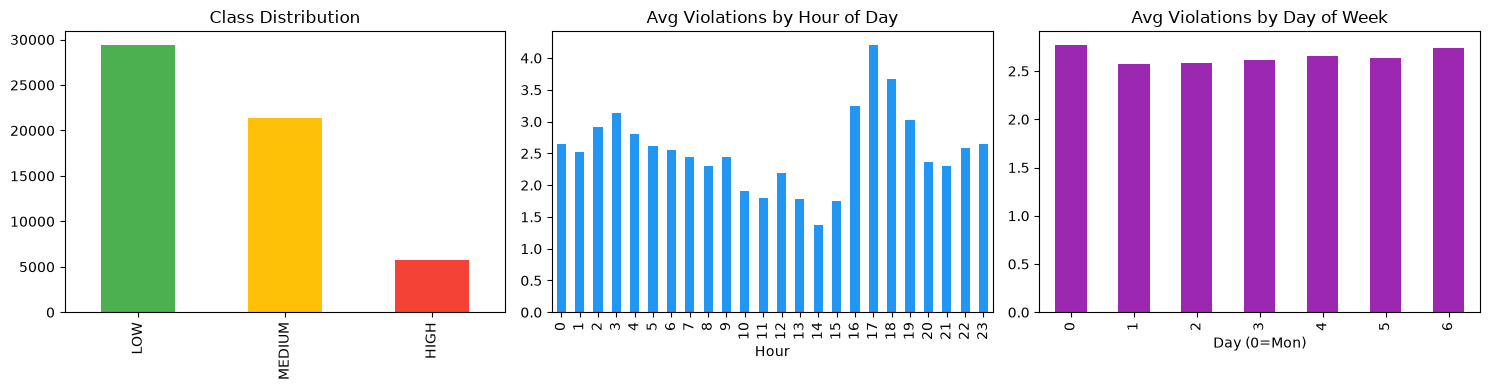

EDA chart saved.


In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Class distribution
zone_hour_df["hotspot_risk"].value_counts().plot.bar(ax=axes[0], color=["#4CAF50","#FFC107","#F44336"])
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("")

# Violations by hour
zone_hour_df.groupby("hour")["total_violations"].mean().plot.bar(ax=axes[1], color="#2196F3")
axes[1].set_title("Avg Violations by Hour of Day")
axes[1].set_xlabel("Hour")

# Violations by day of week
zone_hour_df.groupby("day_of_week")["total_violations"].mean().plot.bar(ax=axes[2], color="#9C27B0")
axes[2].set_title("Avg Violations by Day of Week")
axes[2].set_xlabel("Day (0=Mon)")

plt.tight_layout()
plt.savefig("eda_distributions.png", dpi=120, bbox_inches="tight")
plt.show()
print("EDA chart saved.")

## 15. Train / Test Split (Time-Based)
We split **temporally**: Jan–Apr → train, May → test.  
This is the only correct way to validate a time-series prediction system.

In [18]:
all_dates  = zone_hour_df["hour_bin"].sort_values()
cutoff_dt  = all_dates.quantile(0.80)

train_df = zone_hour_df[zone_hour_df["hour_bin"] <= cutoff_dt].copy()
test_df  = zone_hour_df[zone_hour_df["hour_bin"]  > cutoff_dt].copy()

print(f"80% cutoff: {cutoff_dt}")
print(f"Train: {len(train_df):,} rows | Test: {len(test_df):,} rows")

print(f"Train size: {len(train_df):,} rows  ({train_df['month'].min()}–{train_df['month'].max()} months)")
print(f"Test  size: {len(test_df):,}  rows  (month {test_df['month'].unique().tolist()})")

# ── Final feature columns to keep ────────────────────────────────────────
FEATURE_COLS = [
    "zone_id", "zone_lat", "zone_lon",
    "hour_bin",
    "hour", "day_of_week", "month", "is_weekend",
    "police_station", "junction_name", "junction_flag",
    # violation type breakdown
    "wrong_parking_count", "no_parking_count", "main_road_count",
    "double_parking_count", "near_crossing_count", "near_signal_count",
    "footpath_count",
    # vehicle breakdown
    "heavy_vehicle_count", "medium_vehicle_count",
    "light_vehicle_count", "two_wheel_count",
    # severity
    "avg_vio_severity", "max_vio_severity", "avg_veh_weight",
    # rolling features
    "violations_last_1h", "violations_last_3h",
    "violations_last_24h", "violations_last_7d",
    # repeat / historical
    "repeat_hotspot_score", "zone_total_violations", "historical_zone_log_total",
    # confidence
    "avg_confidence",
    # target (keep both raw + encoded)
    "violations_next_1h", "hotspot_risk", "risk_encoded",
]

# Keep only columns that exist (future-proofing if some were missing)
cols_present = [c for c in FEATURE_COLS if c in train_df.columns]

train_df[cols_present].to_csv(TRAIN_OUT, index=False)
test_df[cols_present].to_csv(TEST_OUT, index=False)

print(f"\n✅ Saved train.csv  ({len(train_df):,} rows, {len(cols_present)} cols)")
print(f"✅ Saved test.csv   ({len(test_df):,}  rows, {len(cols_present)} cols)")

80% cutoff: 2024-03-19 20:00:00+00:00
Train: 45,270 rows | Test: 11,280 rows
Train size: 45,270 rows  (1–3 months)
Test  size: 11,280  rows  (month [4, 3])

✅ Saved train.csv  (45,270 rows, 36 cols)
✅ Saved test.csv   (11,280  rows, 36 cols)


In [19]:
# ── Sanity checks ──────────────────────────────────────────────────────────
print("=== TRAIN SET SANITY CHECK ===")
print(pd.read_csv(TRAIN_OUT).describe(include="all").T[
    ["count","mean","std","min","max","top","freq"]
].to_string())

=== TRAIN SET SANITY CHECK ===
                               count     mean      std     min       max                        top   freq
zone_id                        45270      NaN      NaN     NaN       NaN            Z_12.964_77.577    438
zone_lat                  45270.0000  12.9802   0.0505 12.8180   13.1990                        NaN    NaN
zone_lon                  45270.0000  77.6017   0.0519 77.4450   77.7680                        NaN    NaN
hour_bin                       45270      NaN      NaN     NaN       NaN  2024-01-18 05:00:00+00:00    108
hour                      45270.0000   9.5272   8.3221  0.0000   23.0000                        NaN    NaN
day_of_week               45270.0000   2.9721   1.9704  0.0000    6.0000                        NaN    NaN
month                     45270.0000   1.8444   0.7756  1.0000    3.0000                        NaN    NaN
is_weekend                45270.0000   0.2743   0.4462  0.0000    1.0000                        NaN    NaN
police